# 01 · In-context linear regression (sanity check)

The question this project asks: going from cheap gated linear attention up to MesaNet's exact solve, when is the extra test-time compute worth more than Gated DeltaNet's single-step rule?

This notebook is the smallest first step, a sanity check on a clean, easy version of the task. It is not a result. The goal is to reproduce what the papers already imply and to confirm our setup is correct before trusting it on harder tasks.

## How the experiment is set up

- Train once, test at every difficulty. We train one model across a range of context lengths (the number of in-context examples), then measure held-out error separately at each length. This matches how the layer is actually used: one model, many context lengths.
- Easy task. Noiseless y = Wx with a fixed W. Noise and a moving W come in notebook 02.
- Small and reproducible. 2-layer models, all seeded. Held-out batches use fresh seeds, so the model has to generalize, not memorize.
- Same scoring everywhere, via `synthtasks.metrics.mse_on_queries`, so the model's error and the closed-form best-possible floor are directly comparable.
- Fair starting point for forgetting (disclosed). Out of the box, MesaNet starts by forgetting about half its memory each step, while GDN starts by keeping almost all of it. This task needs every example kept, so the stock Mesa setting is a bad start and makes it look worse than it is. We start both layers from the same keep-almost-everything setting (`MESA_RETENTION`; still trainable). Set it to `None` to see the stock behaviour: GDN looks dominant until about 5x more training, which is a setup artifact, not a real finding.

> Needs a GPU. MesaNet and GatedDeltaNet are flash-linear-attention layers that need CUDA and Triton. Only the CG check (Step 1) runs on CPU.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root: makes `compare` and `synthtasks` importable

import numpy as np
import torch
import matplotlib.pyplot as plt

from compare.experiments import (
    SweepConfig, verify_cg_semantics, check_lambda_collapse,
    regression_examples_sweep, mesa_cg_sweep, mesa_lambda_sweep, oracle_mse_curve,
)
from compare.profile import compute_profile   # FLOPs / throughput / latency / memory (Step 3)

# ----- easily-edited config (shrink `steps` for a quick smoke run) -----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.bfloat16 if DEVICE == "cuda" else torch.float32   # fla chunk kernels prefer bf16 on CUDA

D             = 8                                  # regression key dimension
EVAL_EXAMPLES = [4, 8, 12, 16, 24, 32, 48, 64]     # in-context example counts to evaluate at
CG_GRID       = [1, 2, 5, 10, 30]                  # Mesa CG steps (k=0 is a degenerate floor; see Step 1)
LAMBDA_GRID   = [0.25, 1, 4, 16, 50, 200]          # Mesa ridge regularizer Λ (see Step 1b)
MESA_RETENTION = 4.0                               # Mesa decay-gate bias init (fairness; see design note). None = stock fla
SEED          = 0

cfg = SweepConfig(
    d=D, noise=0.0,
    batch_size=64, steps=600,        # bump `steps` for cleaner curves; lower for a quick smoke run
    hidden_size=128, num_heads=4, num_layers=2,
    eval_batches=4,
    mesa_retention_init=MESA_RETENTION,
    dtype=DTYPE, device=DEVICE,
)
print(f"device={DEVICE}  dtype={DTYPE}  steps={cfg.steps}  mesa_retention_init={cfg.mesa_retention_init}")

device=cuda  dtype=torch.bfloat16  steps=600  mesa_retention_init=4.0


## The data: what the model sees

A quick look at the generator (no model yet): the (x, y) examples laid out as a token stream, and the target value at each query position the model has to predict.

In [2]:
from synthtasks.regression import make_regression  # inline dataset inspection

In [3]:
d, n_examples = 4, 6
inputs, targets, mask = make_regression(
    batch=4, n_examples=n_examples, d=d, noise=0.0, drift=0.0, seed=SEED)

print(f"inputs {inputs.shape}  targets {targets.shape}  mask {mask.shape}   (token dim D = d+1 = {d+1})")
print("\nSequence for example 0  (last channel holds the scalar y):")
for t in range(inputs.shape[1]):
    kind = "x" if mask[0, t] else "y"
    note = f"  <- SCORED query, target y = {targets[0, t]:+.3f}" if mask[0, t] else ""
    print(f"  pos {t:2d} [{kind}]  token = {inputs[0, t]}{note}")

inputs (4, 12, 5)  targets (4, 12)  mask (4, 12)   (token dim D = d+1 = 5)

Sequence for example 0  (last channel holds the scalar y):
  pos  0 [x]  token = [ 0.12573022 -0.13210486  0.64042265  0.10490012  0.        ]  <- SCORED query, target y = -0.454
  pos  1 [y]  token = [ 0.          0.          0.          0.         -0.45418607]
  pos  2 [x]  token = [-0.53566937  0.36159505  1.30400005  0.94708096  0.        ]  <- SCORED query, target y = -1.687
  pos  3 [y]  token = [ 0.          0.          0.          0.         -1.68713795]
  pos  4 [x]  token = [-0.70373524 -1.26542147 -0.62327446  0.04132598  0.        ]  <- SCORED query, target y = +0.703
  pos  5 [y]  token = [0.         0.         0.         0.         0.70283072]
  pos  6 [x]  token = [-2.32503077 -0.21879166 -1.24591095 -0.73226735  0.        ]  <- SCORED query, target y = +1.226
  pos  7 [y]  token = [0.         0.         0.         0.         1.22554221]
  pos  8 [x]  token = [-0.54425898 -0.31630016  0.41163054 

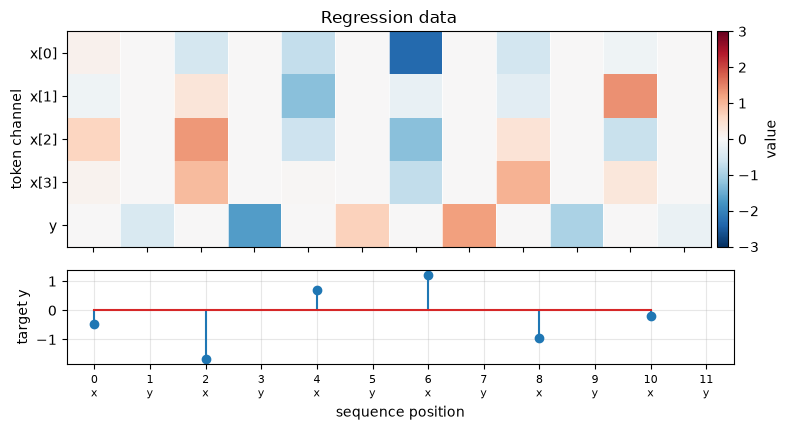

In [4]:
L, D = inputs.shape[1], inputs.shape[2]
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 4.4),
                               gridspec_kw={"height_ratios": [3, 1.3]}, sharex=True)

im = ax0.imshow(inputs[0].T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3)
for t in range(1, L):
    ax0.axvline(t - 0.5, color="w", lw=0.5)
ax0.set_yticks(range(D))
ax0.set_yticklabels([f"x[{i}]" for i in range(d)] + ["y"])
ax0.set_ylabel("token channel")
ax0.set_title("Regression data")
fig.colorbar(im, ax=ax0, fraction=0.025, pad=0.01, label="value")

qpos = np.where(mask[0])[0]
ax1.stem(qpos, targets[0, qpos])
ax1.set_xticks(range(L))
ax1.set_xticklabels([f"{t}\n{'x' if mask[0, t] else 'y'}" for t in range(L)], fontsize=8)
ax1.set_ylabel("target y")
ax1.set_xlabel("sequence position")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/01_regression_data.png", dpi=600, bbox_inches="tight"); plt.show()


## Step 1: a free correctness check on the CG dial

Before comparing anything, we check Mesa's CG dial against the installed kernel, not our memory of the paper. MesaNet produces its answer by solving a small linear system with conjugate gradient (CG); the number of CG steps k is the compute dial.

People often say "k=0 is just gated linear attention (GLA)." In the installed `fla` kernel that is not true. The solver starts from zero, so:

- k=0 gives an output of exactly zero (no mixing at all), a useless floor, not GLA.
- k=1 gives the GLA read-out (up to a per-token scale). This is the real cheap-GLA point.
- large k gives the exact solve.

So the cheap end of the dial here is k=1, and we drop the useless k=0. The check below uses fla's plain-PyTorch reference (CPU, no Triton) and must PASS before we trust anything.

In [5]:
sem = verify_cg_semantics(seed=SEED)
print("CG-semantics check (installed fla kernel, pure-torch CPU reference):")
print(f"  ||o(CG=0)||                  = {sem.cg0_output_norm:.2e}   "
      f"-> {'PASS' if sem.pass_cg0_is_zero else 'FAIL'}: CG=0 is zero (NOT GLA)")
print(f"  CG=1 vs GLA parallelism      = {sem.cg1_vs_gla_parallelism:.2e}   "
      f"-> {'PASS' if sem.pass_cg1_is_gla else 'FAIL'}: CG=1 == GLA up to a scalar")
print(f"  ||o(CG=30)-o_exact||/||..||  = {sem.cg30_rel_error:.2e}   "
      f"-> {'PASS' if sem.pass_converges_to_exact else 'FAIL'}: converges to exact solve")
print(f"\noverall: {'PASS' if sem.all_pass else 'FAIL'}")
assert sem.all_pass, "CG semantics check failed - do not interpret the comparison below."

/home/vzer/Documents/phd/linear_rnn/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CG-semantics check (installed fla kernel, pure-torch CPU reference):
  ||o(CG=0)||                  = 0.00e+00   -> PASS: CG=0 is zero (NOT GLA)
  CG=1 vs GLA parallelism      = 4.42e-07   -> PASS: CG=1 == GLA up to a scalar
  ||o(CG=30)-o_exact||/||..||  = 1.32e-04   -> PASS: converges to exact solve

overall: PASS


## Step 1b: the Λ knob, a second way to collapse to GLA, and what it costs

The CG count is one way to dial Mesa down to the cheap GLA read-out. The ridge term Λ is a second, independent one. Mesa solves x = (H + Λ)⁻¹ q. When Λ is large, (H + Λ)⁻¹ is about 1/Λ, the accumulated history H drops out, and the read-out lands on the same GLA reference as before, up to a constant scale. Two independent knobs (CG toward 1, and Λ large) landing on the same point is strong evidence the code is correct. The check below confirms this at Λ=50 on CPU and must PASS.

The plot shows what that collapse costs. We freeze Λ at a range of values (CG fixed at 30) and plot held-out error vs Λ, with trained GDN as the reference. This is the Λ version of the CG sweep in Step 2.

In [6]:
# --- correctness gate (CPU, fast): large Λ collapses Mesa onto the GLA anchor ---
lam = check_lambda_collapse(seed=SEED)   # paper magnitude Λ = 50·I
print(f"Λ-collapse check (Mesa Λ={lam.lambda_value:.0f}·I vs the same GLA anchor, up to rescale α):")
print(f"  cosine(o_Λ, o_gla)   = {lam.cosine:.6f}   "
      f"-> {'PASS' if lam.pass_directional else 'FAIL'}: collapses to the GLA direction")
print(f"  rescaled query-MSE   = {lam.query_mse:.2e}  (rel {lam.rel_mse:.2e})   "
      f"-> {'PASS' if lam.pass_rescaled else 'FAIL'}: residual << signal   [α≈1/Λ={lam.alpha:.4f}]")
print(f"  overall: {'PASS' if lam.all_pass else 'FAIL'}")
assert lam.all_pass, "Λ-collapse check failed - large-Λ degeneration to GLA does not hold."

# --- performance consequence: held-out MSE as the regularizer Λ grows (trains on GPU) ---
# Pin Mesa's ridge Λ at each value (CG fixed at 30) and measure held-out MSE; GDN is the
# reference. Stronger Λ over-regularizes the in-context solve, so MSE should climb and
# cross the GDN line - Mesa's exact-solve edge only survives at *small* Λ.
lam_sweep = mesa_lambda_sweep(
    lambda_grid=LAMBDA_GRID, eval_examples=EVAL_EXAMPLES,
    train_examples=EVAL_EXAMPLES, mesa_cg=30, seed=SEED, cfg=cfg,
)
lams     = np.array(LAMBDA_GRID, dtype=float)
mesa_mse = np.array([np.mean(lam_sweep["per_lambda"][L]["metric"]) for L in LAMBDA_GRID])
gdn_mse  = float(np.mean(lam_sweep["gdn"]["metric"]))
for L, m in zip(LAMBDA_GRID, mesa_mse):
    print(f"Mesa Λ={L:<5} mean MSE = {m:.3f}")
print(f"Gated DeltaNet  mean MSE = {gdn_mse:.3f}")

# GLA reference: Mesa at CG=1 is the GLA read-out (Step 1), so its held-out MSE is
# where the large-Λ collapse should asymptote. Same config as Step 2's CG=1, so the
# model cache makes this free there.
gla_sweep = mesa_cg_sweep(cg_grid=[1], eval_examples=EVAL_EXAMPLES,
                          train_examples=EVAL_EXAMPLES, with_gdn_reference=False,
                          seed=SEED, cfg=cfg)
gla_mse = float(np.mean(gla_sweep["per_cg"][1]["metric"]))
print(f"GLA (Mesa CG=1)  mean MSE = {gla_mse:.3f}")




Λ-collapse check (Mesa Λ=50·I vs the same GLA anchor, up to rescale α):
  cosine(o_Λ, o_gla)   = 0.999958   -> PASS: collapses to the GLA direction
  rescaled query-MSE   = 2.54e-08  (rel 8.45e-05)   -> PASS: residual << signal   [α≈1/Λ=0.0195]
  overall: PASS
Mesa Λ=0.25  mean MSE = 0.422
Mesa Λ=1     mean MSE = 0.445
Mesa Λ=4     mean MSE = 0.492
Mesa Λ=16    mean MSE = 0.532
Mesa Λ=50    mean MSE = 0.545
Mesa Λ=200   mean MSE = 0.551
Gated DeltaNet  mean MSE = 0.492
GLA (Mesa CG=1)  mean MSE = 0.578


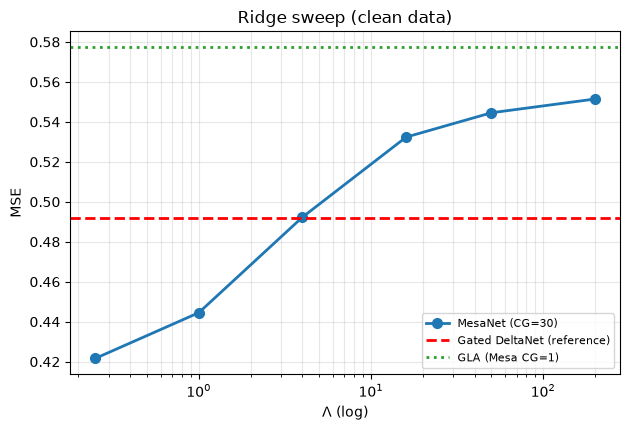

In [7]:
plt.figure(figsize=(6.4, 4.4))
plt.semilogx(lams, mesa_mse, "o-", color="C0", lw=2, ms=7, label="MesaNet (CG=30)")
plt.axhline(gdn_mse, color="r", ls="--", lw=2, label="Gated DeltaNet (reference)")
plt.axhline(gla_mse, color="C2", ls=":", lw=2, label="GLA (Mesa CG=1)")
# plt.fill_between(lams, mesa_mse, gdn_mse, where=(mesa_mse <= gdn_mse),
#                  color="C2", alpha=0.18, label="Mesa below GDN (compute worth it)")
j50 = LAMBDA_GRID.index(50)
# plt.scatter([lams[j50]], [mesa_mse[j50]], s=170, marker="*", color="C3", zorder=5,
#             label="Λ=50 (paper magnitude)")
plt.xlabel("Λ (log)")
plt.ylabel("MSE")
plt.title("Ridge sweep (clean data)")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/01_lambda_sweep.png", dpi=600, bbox_inches="tight"); plt.show()

## Step 2: Mesa CG sweep, from cheap (GLA-like) to exact

Now hold the task fixed and sweep Mesa's compute dial k in {1, 2, 5, 10, 30}. From Step 1, k=1 is the cheap GLA point and larger k approaches the exact solve. GDN is the reference, the cheap incumbent we are asking whether the extra Mesa compute can beat. Mesa at k=30 against the GDN reference is the main comparison.

> Note: GDN's error also depends on context length, so we plot its full curve, not a flat line.

In [8]:
cg_results = mesa_cg_sweep(
    cg_grid=CG_GRID, eval_examples=EVAL_EXAMPLES,
    train_examples=EVAL_EXAMPLES, with_gdn_reference=True, seed=SEED, cfg=cfg,
)
for k in cg_results["cg_grid"]:
    print(f"Mesa CG={k:<2d} MSE = {[round(m, 3) for m in cg_results['per_cg'][k]['metric']]}")

Mesa CG=1  MSE = [0.92, 0.795, 0.672, 0.555, 0.515, 0.455, 0.366, 0.342]
Mesa CG=2  MSE = [0.881, 0.748, 0.57, 0.45, 0.393, 0.329, 0.24, 0.213]
Mesa CG=5  MSE = [0.869, 0.717, 0.55, 0.429, 0.354, 0.279, 0.193, 0.167]
Mesa CG=10 MSE = [0.861, 0.721, 0.544, 0.421, 0.348, 0.276, 0.192, 0.164]
Mesa CG=30 MSE = [0.862, 0.713, 0.54, 0.415, 0.343, 0.273, 0.182, 0.153]


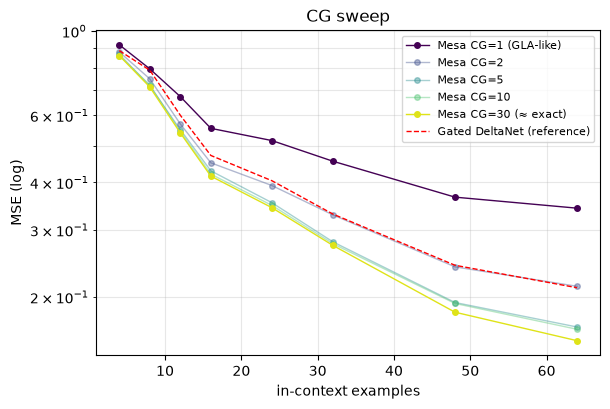

In [9]:
plt.figure(figsize=(6.2, 4.2))
cg_grid = cg_results["cg_grid"]
colors = plt.cm.viridis(np.linspace(0, .95, len(cg_grid)))
for color, k in zip(colors, cg_grid):
    r = cg_results["per_cg"][k]
    tag = " (GLA-like)" if k == 1 else (" (≈ exact)" if k == 30 else "")
    is_outer = k in (cg_grid[0], cg_grid[-1])          # keep the two end curves bold,
    alpha = 1.0 if is_outer else 0.4                    # fade the in-between ones
    plt.plot(r["eval_knobs"], r["metric"], color=color,
             alpha=alpha, label=f"Mesa CG={k}{tag}", marker="o", markersize=4, lw=1)
gdn = cg_results["gdn"]
plt.plot(gdn["eval_knobs"], gdn["metric"], "r--", lw=1, label="Gated DeltaNet (reference)")
plt.yscale("log")
plt.xlabel("in-context examples")
plt.ylabel("MSE (log)")
plt.title("CG sweep")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/01_cg_sweep.png", dpi=600, bbox_inches="tight"); plt.show()